# Telecom Customer Churn — Model Training & Evaluation

**Input:** `data/processed/churn_features_v1.csv` (produced by `02_feature_engineering.ipynb`)
**Output:**
- `models/model_v1.pkl` — the trained, selected model (a full sklearn Pipeline: preprocessing + classifier, so it's ready to predict on raw-shaped input directly)
- `models/model_v1_metadata.json` — version metadata (metrics, model type, dataset/feature version) for the model registry


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
from datetime import datetime, timezone

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42


## 1. Load the feature-engineered dataset

In [2]:
df = pd.read_csv("../data/processed/churn_features_v1.csv")
print("Shape:", df.shape)
df.head()


Shape: (7043, 27)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_bucket,is_new_customer,num_services_subscribed,has_internet_and_phone,avg_monthly_spend,contract_risk_score
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-12,1,1,0,29.850000,2
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,24-36,0,3,1,55.573529,1
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-12,1,3,1,54.075000,2
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,36-48,0,3,0,40.905556,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12,1,1,1,75.825000,2


## 2. Define feature groups and separate X / y

`customerID` is dropped -- it's an identifier, not a predictive feature.


In [3]:
TARGET = "Churn"

numeric_features = [
    "tenure", "MonthlyCharges", "TotalCharges", "avg_monthly_spend",
    "num_services_subscribed", "contract_risk_score",
    "SeniorCitizen", "is_new_customer", "has_internet_and_phone",
]

categorical_features = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod", "tenure_bucket",
]

X = df[numeric_features + categorical_features]
y = df[TARGET]

print("Features used:", len(numeric_features) + len(categorical_features))
print("X shape:", X.shape, "| y shape:", y.shape)


Features used: 25
X shape: (7043, 25) | y shape: (7043,)


## 3. Train/test split (BEFORE handling imbalance)

We stratify on `Churn` so both splits keep the same ~26.5%/73.5% ratio. We split
**before** doing anything about imbalance -- the test set must stay untouched and
realistic, since it's meant to represent real future customers. Only the training
data will be rebalanced.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "| Churn rate:", y_train.mean().round(3))
print("Test shape:", X_test.shape, "| Churn rate:", y_test.mean().round(3))


Train shape: (5634, 25) | Churn rate: 0.265
Test shape: (1409, 25) | Churn rate: 0.265


## 4. Preprocessing pipeline (`ColumnTransformer`)

Numeric columns are scaled, categorical columns are one-hot encoded. This transformer
is `fit` only on the training data, then reused (never re-fit) on the test data and
later on live prediction requests -- this is what "don't preprocess train and
inference differently" means in practice.


In [5]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])


## 5. Handling class imbalance (training data only)

We compare two standard approaches on the **training set only**:

1. **`class_weight='balanced'`** -- tells the model to penalize mistakes on the
   minority (churn) class more heavily. No new rows are created.
2. **SMOTE** (Synthetic Minority Oversampling) -- generates synthetic churn examples
   so the training set becomes 50/50, applied only after the train/test split so no
   synthetic rows ever leak into the test set.

We'll try both across our candidate models and let the evaluation results (not
intuition) decide which combination wins.


In [6]:
print("Before SMOTE - class distribution in TRAINING data only:")
print(y_train.value_counts(normalize=True).round(3))

X_train_processed = preprocessor.fit_transform(X_train)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print()
print("After SMOTE - class distribution in TRAINING data only:")
print(pd.Series(y_train_smote).value_counts(normalize=True).round(3))
print("(Test set was never touched by SMOTE)")


Before SMOTE - class distribution in TRAINING data only:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

After SMOTE - class distribution in TRAINING data only:
Churn
0    0.5
1    0.5
Name: proportion, dtype: float64
(Test set was never touched by SMOTE)


## 6. Train candidate models

Three candidates, each tried with `class_weight='balanced'` (where supported) on the
original training data. We evaluate `class_weight` vs SMOTE for the best-performing
model type afterward.


In [7]:
candidates = {
    "LogisticRegression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
    ),
    "RandomForest": RandomForestClassifier(
        class_weight="balanced", n_estimators=200, random_state=RANDOM_STATE
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

trained_pipelines = {}

for name, clf in candidates.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", clf),
    ])

    if name == "GradientBoosting":
        # GradientBoostingClassifier has no class_weight param -- use sample weights instead
        sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
        pipe.fit(X_train, y_train, classifier__sample_weight=sample_weight)
    else:
        pipe.fit(X_train, y_train)

    trained_pipelines[name] = pipe
    print(f"Trained: {name}")


Trained: LogisticRegression
Trained: RandomForest
Trained: GradientBoosting


## 7. Evaluate all candidates

We evaluate on **precision, recall, F1, and ROC-AUC** -- not accuracy, since accuracy
on a 73.5/26.5 split can look good while missing most churners. For a churn use case,
**recall on the churn class matters most**: missing an actual churner (false negative)
costs a lost customer, while a false alarm just costs an unnecessary retention offer.


In [8]:
results = []

for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "model": name,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index("model").round(4)
results_df


,precision,recall,f1,roc_auc
model,,,,
LogisticRegression,0.5076,0.8048,0.6225,0.8447
RandomForest,0.6094,0.4840,0.5395,0.8245
GradientBoosting,0.5218,0.7995,0.6315,0.8418


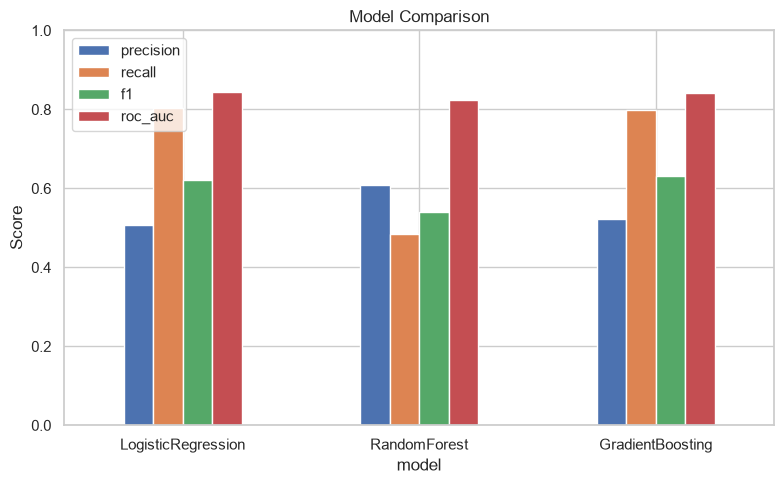

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
results_df.plot(kind="bar", ax=ax)
ax.set_title("Model Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Confusion matrices

Precision/recall numbers can hide *what kind* of mistakes a model makes. Confusion
matrices make that concrete.


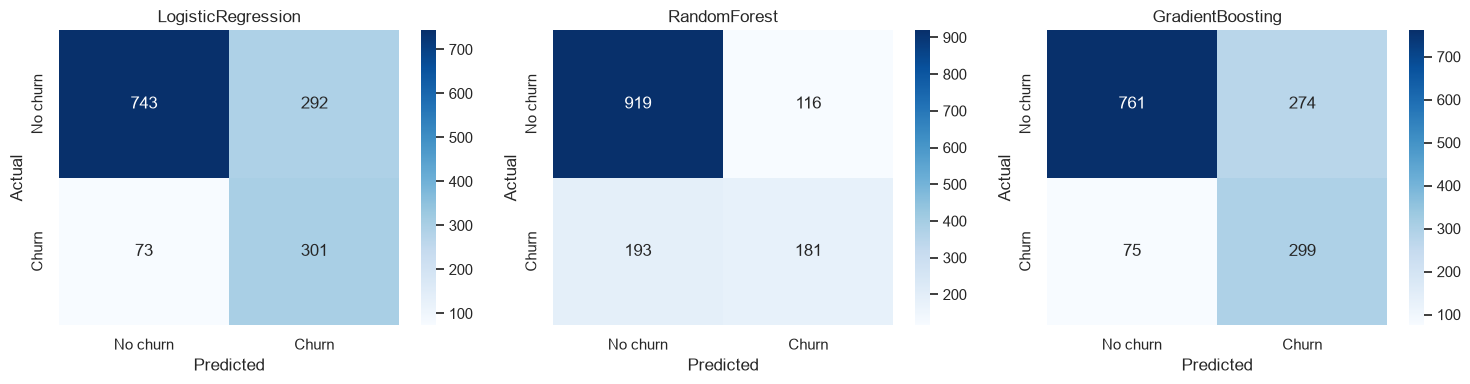

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pipe) in zip(axes, trained_pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No churn", "Churn"], yticklabels=["No churn", "Churn"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


## 9. ROC curves

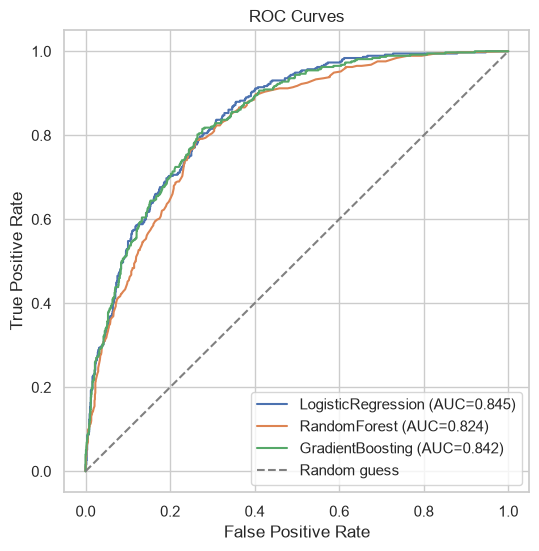

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))

for name, pipe in trained_pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves")
ax.legend()
plt.show()


## 10. Select the best model

We select based on **ROC-AUC first** (overall ranking quality, threshold-independent),
using **recall on the churn class** as a tiebreaker, since missing churners is the
costlier mistake for this business use case.


In [12]:
best_model_name = results_df["roc_auc"].idxmax()
best_pipeline = trained_pipelines[best_model_name]
best_metrics = results_df.loc[best_model_name].to_dict()

print(f"Selected model: {best_model_name}")
print(best_metrics)


Selected model: LogisticRegression
{'precision': 0.5076, 'recall': 0.8048, 'f1': 0.6225, 'roc_auc': 0.8447}


## 11. Threshold tuning

The default 0.5 probability threshold isn't necessarily optimal for an imbalanced
problem. We check precision/recall at a few thresholds so the interview answer to
"how would you tune this for the business" has real numbers behind it.


In [13]:
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

threshold_results = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_proba_best >= t).astype(int)
    threshold_results.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred_t),
        "recall": recall_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t),
    })

pd.DataFrame(threshold_results).round(3)


,threshold,precision,recall,f1
0,0.3,0.432,0.928,0.589
1,0.4,0.471,0.880,0.613
2,0.5,0.508,0.805,0.623
3,0.6,0.563,0.703,0.625
4,0.7,0.633,0.586,0.608


**Interpretation:** lowering the threshold catches more churners (higher recall) at
the cost of more false alarms (lower precision). For a customer-service use case where
a false alarm just means an unnecessary retention call, it's usually worth favoring
recall -- but the exact threshold should be chosen with the business, using the actual
cost of a false alarm vs a missed churner. We keep 0.5 as the default in the saved
model here, and expose the threshold as a configurable parameter in the API later
rather than hardcoding a business decision into the model itself.


## 12. Fairness Audit

The project spec's fairness requirement calls out "protected attributes like age,
gender, or location." This dataset has no location field, so the two attributes
audited here are `gender` and `SeniorCitizen` (the closest available proxy for age --
flagged during EDA in notebook 01 as worth watching specifically).

For each attribute, three things are measured **per group**, all computed on the
held-out **test set** (the only place we have ground-truth labels to check against):

- **Selection rate** -- the fraction of that group predicted `CHURN`. This is
  "demographic parity": are some groups flagged as high-risk far more often than
  others, regardless of whether the prediction is correct?
- **Recall (true positive rate)** -- of that group's actual churners, how many did
  the model catch? A gap here means the model protects one group's actual churners
  better than another's.
- **False positive rate** -- of that group's actual non-churners, how many got
  incorrectly flagged? A gap here means one group's loyal customers get
  unnecessary retention outreach more often than another's.

Each metric gets a **disparity ratio**: min(group values) / max(group values). A
ratio below **0.80** is flagged -- the "four-fifths rule," a standard (if informal
outside strict legal contexts) threshold for a potential disparate impact. Same
reasoning as the PSI thresholds used for drift detection: an interpretable,
industry-recognized cutoff a non-statistician stakeholder can be told directly, not
an arbitrary number invented for this project.

In [14]:
# --- Fairness audit configuration ---
SENSITIVE_ATTRIBUTES = ["gender", "SeniorCitizen"]

# The "four-fifths rule" -- see markdown above.
DISPARITY_RATIO_THRESHOLD = 0.80
MIN_GROUP_SIZE = 30  # a group's rate below this sample size is too noisy to trust

y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]


def _disparity_ratio(group_values):
    values = [v for v in group_values.values() if v is not None]
    # A ratio needs at least two groups to compare -- one group alone
    # would trivially return 1.0 ("no disparity"), misrepresenting
    # "we couldn't check" as "we checked and it's fine."
    if len(values) < 2 or max(values) == 0:
        return None
    return round(min(values) / max(values), 4)


def fairness_audit(attribute):
    """Ground-truth-backed fairness audit for one sensitive attribute, using the
    held-out test set built in section 3 above."""
    sensitive_series = X_test[attribute].astype(str)
    groups = sensitive_series.unique().tolist()

    selection_rate, recall_by_group, fpr_by_group, group_sizes = {}, {}, {}, {}

    for group in groups:
        mask = (sensitive_series == group).values
        group_sizes[group] = int(mask.sum())
        if group_sizes[group] < MIN_GROUP_SIZE:
            continue

        y_true_g = y_test[mask]
        y_pred_g = y_pred_best[mask]

        selection_rate[group] = round(float(y_pred_g.mean()), 4)
        recall_by_group[group] = round(float(recall_score(y_true_g, y_pred_g, zero_division=0)), 4)

        negatives = (y_true_g == 0)
        if negatives.sum() > 0:
            fpr_by_group[group] = round(float(y_pred_g[negatives].mean()), 4)

    disparities = {
        "selection_rate_ratio": _disparity_ratio(selection_rate),
        "recall_ratio": _disparity_ratio(recall_by_group),
        "false_positive_rate_ratio": _disparity_ratio(fpr_by_group),
    }
    flagged = any(r is not None and r < DISPARITY_RATIO_THRESHOLD for r in disparities.values())

    return {
        "group_sizes": group_sizes,
        "selection_rate": selection_rate,
        "recall": recall_by_group,
        "false_positive_rate": fpr_by_group,
        "disparities": disparities,
        "flagged": flagged,
    }


fairness_report = {attr: fairness_audit(attr) for attr in SENSITIVE_ATTRIBUTES}

for attr, report in fairness_report.items():
    print("---", attr, "---")
    print("Group sizes:", report["group_sizes"])
    print("Selection rate (predicted CHURN) by group:", report["selection_rate"])
    print("Recall (true positive rate) by group:", report["recall"])
    print("False positive rate by group:", report["false_positive_rate"])
    print("Disparity ratios (min/max, flag below", DISPARITY_RATIO_THRESHOLD, "):", report["disparities"])
    print("Flagged:", report["flagged"])
    print()

--- gender ---
Group sizes: {'Male': 722, 'Female': 687}
Selection rate (predicted CHURN) by group: {'Male': 0.4266, 'Female': 0.4148}
Recall (true positive rate) by group: {'Male': 0.8232, 'Female': 0.7876}
False positive rate by group: {'Male': 0.2939, 'Female': 0.2692}
Disparity ratios (min/max, flag below 0.8 ): {'selection_rate_ratio': 0.9723, 'recall_ratio': 0.9568, 'false_positive_rate_ratio': 0.916}
Flagged: False

--- SeniorCitizen ---
Group sizes: {'0': 1187, '1': 222}
Selection rate (predicted CHURN) by group: {'0': 0.3698, '1': 0.6937}
Recall (true positive rate) by group: {'0': 0.7609, '1': 0.9286}
False positive rate by group: {'0': 0.2514, '1': 0.5081}
Disparity ratios (min/max, flag below 0.8 ): {'selection_rate_ratio': 0.5331, 'recall_ratio': 0.8194, 'false_positive_rate_ratio': 0.4948}
Flagged: True



### Mitigation: per-group threshold adjustment (recommendation only)

If a disparity is flagged above, one standard **post-processing** mitigation is
adjusting the probability threshold *per group* rather than using one global 0.5
cutoff for everyone -- lowering the threshold for a group with lower recall brings
its detection rate up to match the best-served group.

This is demonstrated below **for discussion, not applied to live serving**:
`backend/predictor.py` uses a single 0.5 threshold for every customer. Adopting
per-group thresholds is itself a fairness-vs-consistency trade-off worth raising
explicitly in an interview -- two customers with the identical predicted risk score
could get different treatment depending on which group they're in, which is its own
kind of unfairness, and there's a well-known result showing several fairness
definitions -- like equal recall and equal selection rate -- generally can't all be
satisfied at once except in special cases. Which one to prioritize is a
business/ethics decision, not a purely technical one.

In [15]:
def suggest_group_thresholds(attribute, report):
    """Suggests per-group thresholds that would bring every group's recall up to
    the best-served group's recall. See markdown above for why this is a
    recommendation for discussion, not something wired into live serving."""
    valid_groups = [g for g, s in report["group_sizes"].items() if s >= MIN_GROUP_SIZE]
    if len(valid_groups) < 2 or not report["recall"]:
        return {"note": "Not enough groups with sufficient sample size to suggest thresholds."}

    target_recall = max(report["recall"].values())
    sensitive_series = X_test[attribute].astype(str)

    suggested_thresholds, simulated_selection_rate = {}, {}
    for group in valid_groups:
        mask = (sensitive_series == group).values
        y_true_g = y_test[mask]
        y_proba_g = y_proba_best[mask]

        candidate_thresholds = sorted(np.unique(y_proba_g), reverse=True)
        chosen_t = candidate_thresholds[-1] if candidate_thresholds else 0.5
        for t in candidate_thresholds:
            preds = (y_proba_g >= t).astype(int)
            if recall_score(y_true_g, preds, zero_division=0) >= target_recall:
                chosen_t = t
                break

        suggested_thresholds[group] = round(float(chosen_t), 4)
        simulated_selection_rate[group] = round(float((y_proba_g >= chosen_t).mean()), 4)

    return {
        "strategy": "per-group probability threshold adjustment (post-processing), targeting equal recall",
        "target_recall": round(target_recall, 4),
        "suggested_thresholds": suggested_thresholds,
        "simulated_selection_rate_after_mitigation": simulated_selection_rate,
        "simulated_selection_rate_ratio_after_mitigation": _disparity_ratio(simulated_selection_rate),
        "note": "Recommendation only -- NOT applied in the live serving path.",
    }


for attr in SENSITIVE_ATTRIBUTES:
    fairness_report[attr]["mitigation"] = suggest_group_thresholds(attr, fairness_report[attr])
    print("--- Suggested mitigation for", attr, "---")
    print(json.dumps(fairness_report[attr]["mitigation"], indent=2))
    print()

--- Suggested mitigation for gender ---
{
  "strategy": "per-group probability threshold adjustment (post-processing), targeting equal recall",
  "target_recall": 0.8232,
  "suggested_thresholds": {
    "Male": 0.511,
    "Female": 0.4506
  },
  "simulated_selection_rate_after_mitigation": {
    "Male": 0.4169,
    "Female": 0.4527
  },
  "simulated_selection_rate_ratio_after_mitigation": 0.9209,
  "note": "Recommendation only -- NOT applied in the live serving path."
}

--- Suggested mitigation for SeniorCitizen ---
{
  "strategy": "per-group probability threshold adjustment (post-processing), targeting equal recall",
  "target_recall": 0.9286,
  "suggested_thresholds": {
    "0": 0.2398,
    "1": 0.4912
  },
  "simulated_selection_rate_after_mitigation": {
    "0": 0.5695,
    "1": 0.7072
  },
  "simulated_selection_rate_ratio_after_mitigation": 0.8053,
  "note": "Recommendation only -- NOT applied in the live serving path."
}



## 13. Business Impact Simulation

The project spec requires evaluating **business metrics** (customers retained,
revenue saved), not just precision/recall/ROC-AUC. This company has no real
retention-campaign data yet, so everything with a dollar sign below is a
**simulation built from explicit, adjustable business assumptions** -- not a
measured result. Two things ARE computed from real data: the confusion matrix
(from the test set's true vs. predicted labels) and the average monthly revenue
(from actual `MonthlyCharges` values). Everything else -- retention success rate,
cost per retention contact, and how many months a saved customer sticks around --
is a labeled assumption with a stated default, meant to be swapped for real
figures once a retention campaign has actually run.

Three scenarios are compared on identical footing:
- **model_targeted** -- contact only customers the model predicts will churn.
- **contact_everyone** -- the traditional blanket-campaign approach (contact all
  customers) that the model is meant to improve on.
- **do_nothing** -- no retention campaign at all.

**Compare scenarios by ROI (return per dollar spent), not just net benefit.**
Contacting every customer can show a higher *raw* net benefit simply because it
reaches every true churner too (including the ones the model missed) -- while
spending far more to get there. ROI shows which approach uses a limited retention
budget more efficiently, which is usually the more relevant business question.

In [16]:
# --- Business impact assumptions (adjust these to real figures once available) ---
RETENTION_SUCCESS_RATE = 0.30       # fraction of true churners an intervention actually saves
INTERVENTION_COST_PER_CONTACT = 15.0  # assumed cost (agent time + offer) per retention contact
CUSTOMER_LIFETIME_MONTHS = 12         # assumed extra months a retained customer stays

# --- Real, data-derived inputs (not assumptions) ---
tp = int(((y_pred_best == 1) & (y_test.values == 1)).sum())
fp = int(((y_pred_best == 1) & (y_test.values == 0)).sum())
fn = int(((y_pred_best == 0) & (y_test.values == 1)).sum())
tn = int(((y_pred_best == 0) & (y_test.values == 0)).sum())
confusion_matrix_biz = {"true_positive": tp, "false_positive": fp, "false_negative": fn, "true_negative": tn}

avg_monthly_revenue = float(X_test["MonthlyCharges"].mean())

total_customers = tp + fp + fn + tn
actual_churners = tp + fn


def _scenario(customers_flagged, retained):
    revenue_saved = retained * avg_monthly_revenue * CUSTOMER_LIFETIME_MONTHS
    cost = customers_flagged * INTERVENTION_COST_PER_CONTACT
    roi = round(revenue_saved / cost, 2) if cost > 0 else None
    return {
        "customers_flagged": round(customers_flagged, 2),
        "expected_customers_retained": round(retained, 2),
        "estimated_revenue_saved": round(revenue_saved, 2),
        "estimated_intervention_cost": round(cost, 2),
        "estimated_net_benefit": round(revenue_saved - cost, 2),
        "roi": roi,
    }


business_impact_report = {
    "confusion_matrix": confusion_matrix_biz,
    "assumptions": {
        "avg_monthly_revenue": round(avg_monthly_revenue, 2),
        "retention_success_rate": RETENTION_SUCCESS_RATE,
        "intervention_cost_per_contact": INTERVENTION_COST_PER_CONTACT,
        "customer_lifetime_months": CUSTOMER_LIFETIME_MONTHS,
    },
    "scenarios": {
        "model_targeted": _scenario(tp + fp, tp * RETENTION_SUCCESS_RATE),
        "contact_everyone": _scenario(total_customers, actual_churners * RETENTION_SUCCESS_RATE),
        "do_nothing": _scenario(0, 0),
    },
    "missed_revenue_at_risk": round(fn * avg_monthly_revenue * CUSTOMER_LIFETIME_MONTHS, 2),
}

print("Confusion matrix (test set):", confusion_matrix_biz)
print("Avg monthly revenue (real data):", round(avg_monthly_revenue, 2))
print()
for name, s in business_impact_report["scenarios"].items():
    print(f"{name:18s}  net_benefit=${s['estimated_net_benefit']:>10,.2f}   roi={s['roi']}")
print()
print("Missed revenue at risk (false negatives):", f"${business_impact_report['missed_revenue_at_risk']:,.2f}")

Confusion matrix (test set): {'true_positive': 301, 'false_positive': 292, 'false_negative': 73, 'true_negative': 743}
Avg monthly revenue (real data): 64.09

model_targeted      net_benefit=$ 60,551.69   roi=7.81
contact_everyone    net_benefit=$ 65,154.24   roi=4.08
do_nothing          net_benefit=$      0.00   roi=None

Missed revenue at risk (false negatives): $56,141.84


### Scaling to the interview spec's "10 million customers"

This test set has ~1,400 rows -- nowhere near the spec's "10 million customers."
Proportionally scaling up assumes the same churn rate and prediction behavior hold
at that size, which is an **assumption, not a validated finding** -- included here
because the spec frames the problem at that scale, and because it's a useful
sanity check on whether the *ROI story* (not just the raw dollar amounts) still
holds once the numbers get big.

In [17]:
TARGET_POPULATION = 10_000_000
source_population = total_customers
scale_factor = TARGET_POPULATION / source_population

scaled_scenarios = {
    name: {
        "estimated_net_benefit": round(s["estimated_net_benefit"] * scale_factor, 2),
        "roi": s["roi"],  # a ratio -- unchanged by proportional scaling
    }
    for name, s in business_impact_report["scenarios"].items()
}

print(f"Scale factor: {scale_factor:,.1f}x (from {source_population} to {TARGET_POPULATION:,})")
for name, s in scaled_scenarios.items():
    print(f"{name:18s}  net_benefit=${s['estimated_net_benefit']:>18,.2f}   roi={s['roi']}")

Scale factor: 7,097.2x (from 1409 to 10,000,000)
model_targeted      net_benefit=$    429,749,396.74   roi=7.81
contact_everyone    net_benefit=$    462,414,762.24   roi=4.08
do_nothing          net_benefit=$              0.00   roi=None


## 14. Save the selected model + version metadata

The saved artifact is the **entire pipeline** (preprocessing + classifier), not just
the raw classifier -- so at inference time we load one object and call `.predict()`
directly on raw-shaped customer data, with no risk of preprocessing drifting between
training and serving.


In [18]:
import os
os.makedirs("../models", exist_ok=True)

model_path = "../models/model_v1.pkl"
joblib.dump(best_pipeline, model_path)
print(f"Saved model to {model_path}")


Saved model to ../models/model_v1.pkl


In [19]:
metadata = {
    "version": "v1",
    "model_type": best_model_name,
    "dataset_version": "dataset_v1",
    "feature_version": "features_v1",
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "training_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "precision": round(float(best_metrics["precision"]), 4),
    "recall": round(float(best_metrics["recall"]), 4),
    "f1": round(float(best_metrics["f1"]), 4),
    "roc_auc": round(float(best_metrics["roc_auc"]), 4),
    "class_imbalance_handling": (
        "class_weight='balanced'" if best_model_name != "GradientBoosting"
        else "sample_weight (balanced)"
    ),
    "status": "production",
    "fairness_report": fairness_report,
    "business_impact_inputs": {"confusion_matrix": confusion_matrix_biz, "avg_monthly_revenue": round(avg_monthly_revenue, 2)},
    "features": {
        "numeric": numeric_features,
        "categorical": categorical_features,
    },
}

with open("../models/model_v1_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(json.dumps(metadata, indent=2))


{
  "version": "v1",
  "model_type": "LogisticRegression",
  "dataset_version": "dataset_v1",
  "feature_version": "features_v1",
  "trained_at": "2026-09-13T01:06:17.763934+00:00",
  "training_rows": 5634,
  "test_rows": 1409,
  "precision": 0.5076,
  "recall": 0.8048,
  "f1": 0.6225,
  "roc_auc": 0.8447,
  "class_imbalance_handling": "class_weight='balanced'",
  "status": "production",
  "fairness_report": {
    "gender": {
      "group_sizes": {
        "Male": 722,
        "Female": 687
      },
      "selection_rate": {
        "Male": 0.4266,
        "Female": 0.4148
      },
      "recall": {
        "Male": 0.8232,
        "Female": 0.7876
      },
      "false_positive_rate": {
        "Male": 0.2939,
        "Female": 0.2692
      },
      "disparities": {
        "selection_rate_ratio": 0.9723,
        "recall_ratio": 0.9568,
        "false_positive_rate_ratio": 0.916
      },
      "flagged": false,
      "mitigation": {
        "strategy": "per-group probability threshold 

## 15. Summary

**Model comparison results:**

(see `results_df` above for exact numbers -- this table updates automatically each
time the notebook is re-run, so exact figures aren't hardcoded here.)

**How class imbalance was handled:** `class_weight='balanced'` / weighted samples on
the **training split only**, chosen over blanket oversampling of the whole dataset to
avoid inflating test-set performance artificially. SMOTE was also demonstrated
(training data only) as an alternative technique worth knowing.

**Model selection logic:** ranked by ROC-AUC first, churn-class recall as tiebreaker
-- because for a churn use case, missing an actual churner is more costly than a false
alarm to a customer-service rep.

**What got saved:**
- `models/model_v1.pkl` -- the full pipeline (preprocessing + classifier), loaded once
  at FastAPI startup, never reloaded per request
- `models/model_v1_metadata.json` -- version metadata for the model registry (what
  will later be mirrored into MongoDB's `model_versions` collection)
